In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
'''
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

'''

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')



In [2]:
import os
import pandas as pd
import numpy as np

from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
import json

import matplotlib.pyplot as plt
import seaborn as sns
import torch

from PIL import Image

from torch import nn
from torch.utils.data import Dataset, DataLoader

from transformers import AutoImageProcessor
from transformers import ViTForImageClassification

from tqdm.auto import tqdm


SEED = 42

# No Kaggle, o caminho base sempre começa com /kaggle/input/
base_dir = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'

# Listando as pastas disponíveis no dataset para conferir os nomes
print("Conteúdo do dataset:", os.listdir(base_dir))

# Carregando o arquivo CSV de metadados
metadata_path = os.path.join(base_dir, 'HAM10000_metadata.csv')
df = pd.read_csv(metadata_path)

print(f"\nTotal de imagens registradas: {len(df)}")
df.head()

Conteúdo do dataset: ['hmnist_8_8_RGB.csv', 'hmnist_28_28_RGB.csv', 'HAM10000_images_part_1', 'ham10000_images_part_1', 'hmnist_8_8_L.csv', 'HAM10000_images_part_2', 'ham10000_images_part_2', 'hmnist_28_28_L.csv', 'HAM10000_metadata.csv']

Total de imagens registradas: 10015


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


# pre-processing

In [3]:
label_map = {
    'nv':    0,
    'mel':   1,
    'bkl':   2,
    'bcc':   3,
    'akiec': 4,
    'vasc':  5,
    'df':    6
}

df['label'] = df['dx'].map(label_map)

print("Mapeamento de classes:")
for k, v in label_map.items():
    print(f"  {v} → {k}")

Mapeamento de classes:
  0 → nv
  1 → mel
  2 → bkl
  3 → bcc
  4 → akiec
  5 → vasc
  6 → df


In [4]:
imageid_path = {}
for dirname, _, filenames in os.walk(base_dir+'/ham10000_images_part_1'):
    for filename in filenames:
        # print(os.path.join(dirname, filename))
        # print(filename[:-4])
        imageid_path[filename[:-4]] = os.path.join(dirname, filename)
        
for dirname, _, filenames in os.walk(base_dir+'/ham10000_images_part_2'):
    for filename in filenames:
        # print(os.path.join(dirname, filename))
        # print(filename[:-4])
        imageid_path[filename[:-4]] = os.path.join(dirname, filename)


df['filepath'] = df['image_id'].map(imageid_path.get)

In [5]:
missing = df[~df['filepath'].apply(lambda x: Path(x).exists())]
print(f"Imagens faltando: {len(missing)}")

Imagens faltando: 0


In [6]:
# Primeiro split: separa teste (15%) do restante (85%)
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
remaining_idx, test_idx = next(gss_test.split(df, df['label'], groups=df['lesion_id']))

df_remaining = df.iloc[remaining_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

# Segundo split: separa validação (15% do restante) de treino
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
train_idx, val_idx = next(gss_val.split(df_remaining, df_remaining['label'], groups=df_remaining['lesion_id']))

df_train = df_remaining.iloc[train_idx].reset_index(drop=True)
df_val = df_remaining.iloc[val_idx].reset_index(drop=True)

print(f"Treino:    {len(df_train)} imagens ({len(df_train)/len(df)*100:.1f}%)")
print(f"Validação: {len(df_val)} imagens ({len(df_val)/len(df)*100:.1f}%)")
print(f"Teste:     {len(df_test)} imagens ({len(df_test)/len(df)*100:.1f}%)")

Treino:    7182 imagens (71.7%)
Validação: 1306 imagens (13.0%)
Teste:     1527 imagens (15.2%)


In [7]:
train_lesions = set(df_train['lesion_id'])
val_lesions = set(df_val['lesion_id'])
test_lesions = set(df_test['lesion_id'])

print(f"Vazamento treino/val:   {len(train_lesions & val_lesions)} lesion_ids em comum")
print(f"Vazamento treino/teste: {len(train_lesions & test_lesions)} lesion_ids em comum")
print(f"Vazamento val/teste:    {len(val_lesions & test_lesions)} lesion_ids em comum")

Vazamento treino/val:   0 lesion_ids em comum
Vazamento treino/teste: 0 lesion_ids em comum
Vazamento val/teste:    0 lesion_ids em comum


In [8]:
# Cálculo de pesos de classe para lidar com desbalanceamento
from sklearn.utils.class_weight import compute_class_weight

classes = np.array(sorted(df_train['label'].unique()))
weights = compute_class_weight('balanced', classes=classes, y=df_train['label'])
class_weights = dict(zip(classes.tolist(), weights.tolist()))

print("Class weights:")
inv_label_map = {v: k for k, v in label_map.items()}
for cls, w in class_weights.items():
    print(f"  {inv_label_map[cls]:<8} → {w:.4f}")

Class weights:
  nv       → 0.2133
  mel      → 1.2857
  bkl      → 1.2955
  bcc      → 2.7956
  akiec    → 4.5398
  vasc     → 10.4694
  df       → 11.1522


In [44]:
# Cálculo de pesos de classe para lidar com desbalanceamento
from sklearn.utils.class_weight import compute_class_weight

classes = np.array(sorted(df_train['label'].unique()))
weights = compute_class_weight('balanced', classes=classes, y=df_train['label'])
class_weights = dict(zip(classes.tolist(), weights.tolist()))

print("Class weights:")
inv_label_map = {v: k for k, v in label_map.items()}
for cls, w in class_weights.items():
    print(f"  {inv_label_map[cls]:<8} → {w:.4f}")

Class weights:
  nv       → 2.5133
  mel      → 1.5477
  bkl      → 0.7172
  bcc      → 6.1739
  akiec    → 0.7118
  vasc     → 0.3543
  df       → 5.7959


In [10]:
PROCESSED_DIR = Path('/kaggle/input/datasets/jonhlucasalves/processed-data')

In [1]:
# Salva os conjuntos de dados e os pesos de classe em arquivos CSV e JSON
'''
df_train.to_csv(PROCESSED_DIR / "train.csv", index=False)
df_val.to_csv(PROCESSED_DIR / "val.csv", index=False)
df_test.to_csv(PROCESSED_DIR / "test.csv", index=False)

with open(PROCESSED_DIR / "class_weights.json", "w") as f:
    json.dump(class_weights, f, indent=2)

print("Arquivos salvos:")
print(f"  train.csv     → {len(df_train)} linhas")
print(f"  val.csv       → {len(df_val)} linhas")
print(f"  test.csv      → {len(df_test)} linhas")
print(f"  class_weights.json")
'''

'\ndf_train.to_csv(PROCESSED_DIR / "train.csv", index=False)\ndf_val.to_csv(PROCESSED_DIR / "val.csv", index=False)\ndf_test.to_csv(PROCESSED_DIR / "test.csv", index=False)\n\nwith open(PROCESSED_DIR / "class_weights.json", "w") as f:\n    json.dump(class_weights, f, indent=2)\n\nprint("Arquivos salvos:")\nprint(f"  train.csv     → {len(df_train)} linhas")\nprint(f"  val.csv       → {len(df_val)} linhas")\nprint(f"  test.csv      → {len(df_test)} linhas")\nprint(f"  class_weights.json")\n'

# Data augum

In [9]:
print(df_train['dx'].value_counts())


df_transform = df_train.query("dx != 'nv'")

print(df_transform['dx'].value_counts())

# df_transform



dx
nv       4809
mel       798
bkl       792
bcc       367
akiec     226
vasc       98
df         92
Name: count, dtype: int64
dx
mel      798
bkl      792
bcc      367
akiec    226
vasc      98
df        92
Name: count, dtype: int64


In [45]:
print(df_train['dx'].value_counts())



dx
nv       4809
mel      2394
bkl      2376
bcc      1101
akiec     678
vasc      294
df        276
Name: count, dtype: int64


In [10]:
from tqdm.auto import tqdm
from torchvision import transforms



In [11]:
OUTPUT_DIR = "/kaggle/working/augmented_data/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

new_data = df_transform.copy()
new_metadata_rows = []

NUM_AUGMENTATIONS_PER_IMAGE = 2

augmentation_pipeline = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=35),
    transforms.ColorJitter(brightness=0.15, contrast=0.15)
])

for idx, row in tqdm(df_transform.iterrows(), total=len(df_transform)):
    image_id = row['image_id']
    
    img_path = row['filepath']

    if os.path.exists(img_path):
        # Abrir imagem original usando PIL
        original_img = Image.open(img_path).convert('RGB')

        base_output_path = os.path.join(OUTPUT_DIR, f"{image_id}.jpg")
        if not os.path.exists(base_output_path):
            row['filepath'] = base_output_path#OUTPUT_DIR + image_id + ".jpg"
            original_img.resize((224, 224)).save(base_output_path, 'JPEG')
            new_metadata_rows.append(row) # Mantém a linha original para o novo CSV
       
        for i in range(NUM_AUGMENTATIONS_PER_IMAGE):
            augmented_img = augmentation_pipeline(original_img)
            
            # Definir novo ID único para a imagem modificada
            new_image_id = f"{image_id}_aug_{i}"
            output_file_path = os.path.join(OUTPUT_DIR, f"{new_image_id}.jpg")
            
            if not os.path.exists(output_file_path):
                # Salva fisicamente a imagem transformada no disco rígido do Kaggle
                augmented_img.save(output_file_path, 'JPEG')
                
                # Copiar os metadados originais da linha e atualizar o ID da imagem
                new_row = row.copy()
                new_row['image_id'] = new_image_id
                new_row['filepath'] = output_file_path
                new_metadata_rows.append(new_row)

  0%|          | 0/2373 [00:00<?, ?it/s]

In [15]:
print(len(new_metadata_rows))
new_metadata_rows[2]['filepath']
# new_data.to_csv('/kaggle/working/augmented_metadata.csv', index=False)

11928


'/kaggle/working/augmented_data/ISIC_0027419_aug_1.jpg'

In [14]:
for idx, row in tqdm(df_train.iterrows(), total=len(df_train)):
    image_id = row['image_id']
    
    img_path = row['filepath']

    if os.path.exists(img_path):
        # Abrir imagem original usando PIL
        original_img = Image.open(img_path).convert('RGB')

        base_output_path = os.path.join(OUTPUT_DIR, f"{image_id}.jpg")
        if not os.path.exists(base_output_path):
            row['filepath'] = base_output_path#OUTPUT_DIR + image_id + ".jpg"
            original_img.resize((224, 224)).save(base_output_path, 'JPEG')
            new_metadata_rows.append(row) # Mantém a linha original para o novo CSV
       

  0%|          | 0/7182 [00:00<?, ?it/s]

# Treino

In [22]:
processedData = pd.DataFrame(new_metadata_rows, columns=df_transform.keys())

print(processedData.info())

print(processedData['image_id'].nunique())

<class 'pandas.core.frame.DataFrame'>
Index: 11928 entries, 0 to 6954
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     11928 non-null  object 
 1   image_id      11928 non-null  object 
 2   dx            11928 non-null  object 
 3   dx_type       11928 non-null  object 
 4   age           11871 non-null  float64
 5   sex           11928 non-null  object 
 6   localization  11928 non-null  object 
 7   label         11928 non-null  int64  
 8   filepath      11928 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 931.9+ KB
None
11928


In [17]:
processedData.to_csv('/kaggle/working/augmented_metadata.csv', index=False)

In [23]:
df_train = processedData.copy()

In [24]:
encoder = LabelEncoder()

df_train["label"] = encoder.fit_transform(df_train["dx"])
df_test["label"] = encoder.fit_transform(df_test["dx"])
df_val["label"] = encoder.fit_transform(df_val["dx"])

num_classes = len(encoder.classes_)
print(num_classes)

7


In [46]:
print(df_train['filepath'].head(3))
print(df_train['label'].unique())

0      /kaggle/working/augmented_data/ISIC_0027419.jpg
0    /kaggle/working/augmented_data/ISIC_0027419_au...
0    /kaggle/working/augmented_data/ISIC_0027419_au...
Name: filepath, dtype: object
[2 3 4 6 1 0 5]


In [30]:
processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224", use_fast=True)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

In [31]:
class HAMDataset(Dataset):

    def __init__(self, dataframe, processor):
        self.df = dataframe.reset_index(drop=True)

        self.images = []
        self.labels = []

        for _, row in self.df.iterrows():

            image = Image.open(row.filepath).convert("RGB")

            tensor = processor(
                image,
                return_tensors="pt"
            )["pixel_values"][0]

            self.images.append(tensor)
            self.labels.append(row.label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

train_loader = DataLoader(
    HAMDataset(df_train, processor),
    batch_size=32,
    shuffle=True,
    num_workers=os.cpu_count(),
    persistent_workers=True,
    prefetch_factor=2
)

val_loader = DataLoader(
    HAMDataset(df_val, processor),
    batch_size=64,
    shuffle=False,
    num_workers=os.cpu_count(),
    persistent_workers=True
)

test_loader = DataLoader(
    HAMDataset(df_test, processor),
    batch_size=64,
    shuffle=False,
    num_workers=os.cpu_count(),
    persistent_workers=True
)
'''
train_loader = DataLoader(
    HAMDataset(df_train),
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    HAMDataset(df_test),
    batch_size=32
)

val_dataloader = DataLoader(
    HAMDataset(df_val),
    batch_size=32
)
'''

'\ntrain_loader = DataLoader(\n    HAMDataset(df_train),\n    batch_size=32,\n    shuffle=True\n)\n\ntest_loader = DataLoader(\n    HAMDataset(df_test),\n    batch_size=32\n)\n\nval_dataloader = DataLoader(\n    HAMDataset(df_val),\n    batch_size=32\n)\n'

In [32]:
model = ViTForImageClassification.from_pretrained(

    "google/vit-base-patch16-224",

    num_labels=num_classes,

    ignore_mismatched_sizes=True
)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([7])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([7, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [33]:
incremented_classifier = nn.Sequential(
    nn.Linear(768,512),
    nn.BatchNorm1d(512),
    nn.GELU(),
    nn.Dropout(0.4),
    nn.Linear(512,256),
    nn.BatchNorm1d(256),
    nn.GELU(),
    nn.Dropout(0.3),
    nn.Linear(256,7)
)
# 3. Substitui a camada simples pela nova estrutura
model.classifier = incremented_classifier

print(model.classifier)

Sequential(
  (0): Linear(in_features=768, out_features=512, bias=True)
  (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): GELU(approximate='none')
  (3): Dropout(p=0.4, inplace=False)
  (4): Linear(in_features=512, out_features=256, bias=True)
  (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): GELU(approximate='none')
  (7): Dropout(p=0.3, inplace=False)
  (8): Linear(in_features=256, out_features=7, bias=True)
)


In [36]:
for param in model.vit.parameters():
    param.requires_grad = False

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)
model.to(device)

cuda


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [38]:
epochs = 10

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(df_train.label),
    y=df_train.label
)
print(weights)
weights = torch.tensor(weights, dtype=torch.float).to(device)


criterion = nn.CrossEntropyLoss(weight=weights)
# criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(model.parameters(), 
                              lr=1e-4, 
                              weight_decay=1e-4)
'''
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=epochs
)
'''
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

[2.51327434 1.54768392 0.71717172 6.17391304 0.71177945 0.35433562
 5.79591837]


In [41]:
'''

for epoch in range(epochs):

    model.train()
    running_loss = 0.0

    pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                desc=f"Epoch {epoch+1}/{epochs}")

    for i, (images, labels) in pbar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs.logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        pbar.set_postfix(
            loss=f"{loss.item():.4f}",
            avg_loss=f"{running_loss/(i+1):.4f}"
        )


for epoch in range(epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs.logits, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    # <<< aqui você faz a validação >>>
    val_loss, val_acc = evaluate(...)

    # <<< e somente depois atualiza o scheduler >>>
    scheduler.step()

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss={running_loss/len(train_loader):.4f} | "
        f"Val Loss={val_loss:.4f}"
    )
'''

'\nfrom tqdm.auto import tqdm\n\nfor epoch in range(epochs):\n\n    model.train()\n    running_loss = 0.0\n\n    pbar = tqdm(enumerate(train_loader), total=len(train_loader),\n                desc=f"Epoch {epoch+1}/{epochs}")\n\n    for i, (images, labels) in pbar:\n\n        images = images.to(device)\n        labels = labels.to(device)\n\n        optimizer.zero_grad()\n\n        outputs = model(images)\n        loss = criterion(outputs.logits, labels)\n\n        loss.backward()\n        optimizer.step()\n\n        running_loss += loss.item()\n\n        pbar.set_postfix(\n            loss=f"{loss.item():.4f}",\n            avg_loss=f"{running_loss/(i+1):.4f}"\n        )\n\n\nfor epoch in range(epochs):\n\n    model.train()\n\n    running_loss = 0\n    correct = 0\n    total = 0\n\n    for images, labels in train_loader:\n\n        images = images.to(device)\n        labels = labels.to(device)\n\n        optimizer.zero_grad()\n\n        outputs = model(images)\n\n        loss = criteri

In [39]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_recall_fscore_support

def evaluate(model, dataloader, criterion, device):

    model.eval()

    running_loss = 0.0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs.logits, labels)

            running_loss += loss.item()

            preds = outputs.logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    loss = running_loss / len(dataloader)

    accuracy = accuracy_score(all_labels, all_preds)

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return {
        "loss": loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": []
}

In [56]:
epochs = 10

In [57]:

for epoch in range(epochs):

    model.train()

    # running_loss = 0.0

    # correct = 0
    # total = 0

    pbar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{epochs}",
        leave=True
    )

    for images, labels in pbar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs.logits, labels)

        loss.backward()

        optimizer.step()

        preds = outputs.logits.argmax(dim=1)

        running_loss += loss.item()

        correct += (preds == labels).sum().item()

        total += labels.size(0)

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{100*correct/total:.2f}%"
        })

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    metrics = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(metrics["loss"])
    # scheduler.step()


    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(metrics["loss"])
    history["val_acc"].append(metrics["accuracy"])
    history["val_f1"].append(metrics["f1"])

    print(
        f"\nEpoch {epoch+1}/{epochs}"
        f"\nTrain Loss : {train_loss:.4f}"
        f"\nTrain Acc  : {train_acc:.4f}"
        f"\nVal Loss   : {metrics['loss']:.4f}"
        f"\nVal Acc    : {metrics['accuracy']:.4f}"
        f"\nVal F1     : {metrics['f1']:.4f}"
    )

Epoch 1/10:   0%|          | 0/373 [00:00<?, ?it/s]


Epoch 1/10
Train Loss : 0.5853
Train Acc  : 0.8703
Val Loss   : 0.9365
Val Acc    : 0.7113
Val F1     : 0.5224


Epoch 2/10:   0%|          | 0/373 [00:00<?, ?it/s]


Epoch 2/10
Train Loss : 0.8506
Train Acc  : 0.8736
Val Loss   : 1.0013
Val Acc    : 0.7014
Val F1     : 0.5111


Epoch 3/10:   0%|          | 0/373 [00:00<?, ?it/s]

...


Epoch 8/10
Train Loss : 2.2883
Train Acc  : 0.8849
Val Loss   : 0.9572
Val Acc    : 0.7221
Val F1     : 0.5155


Epoch 9/10:   0%|          | 0/373 [00:00<?, ?it/s]


Epoch 9/10
Train Loss : 2.5042
Train Acc  : 0.8862
Val Loss   : 0.9674
Val Acc    : 0.7129
Val F1     : 0.5106


Epoch 10/10:   0%|          | 0/373 [00:00<?, ?it/s]


Epoch 10/10
Train Loss : 2.7156
Train Acc  : 0.8874
Val Loss   : 0.9476
Val Acc    : 0.7266
Val F1     : 0.5209


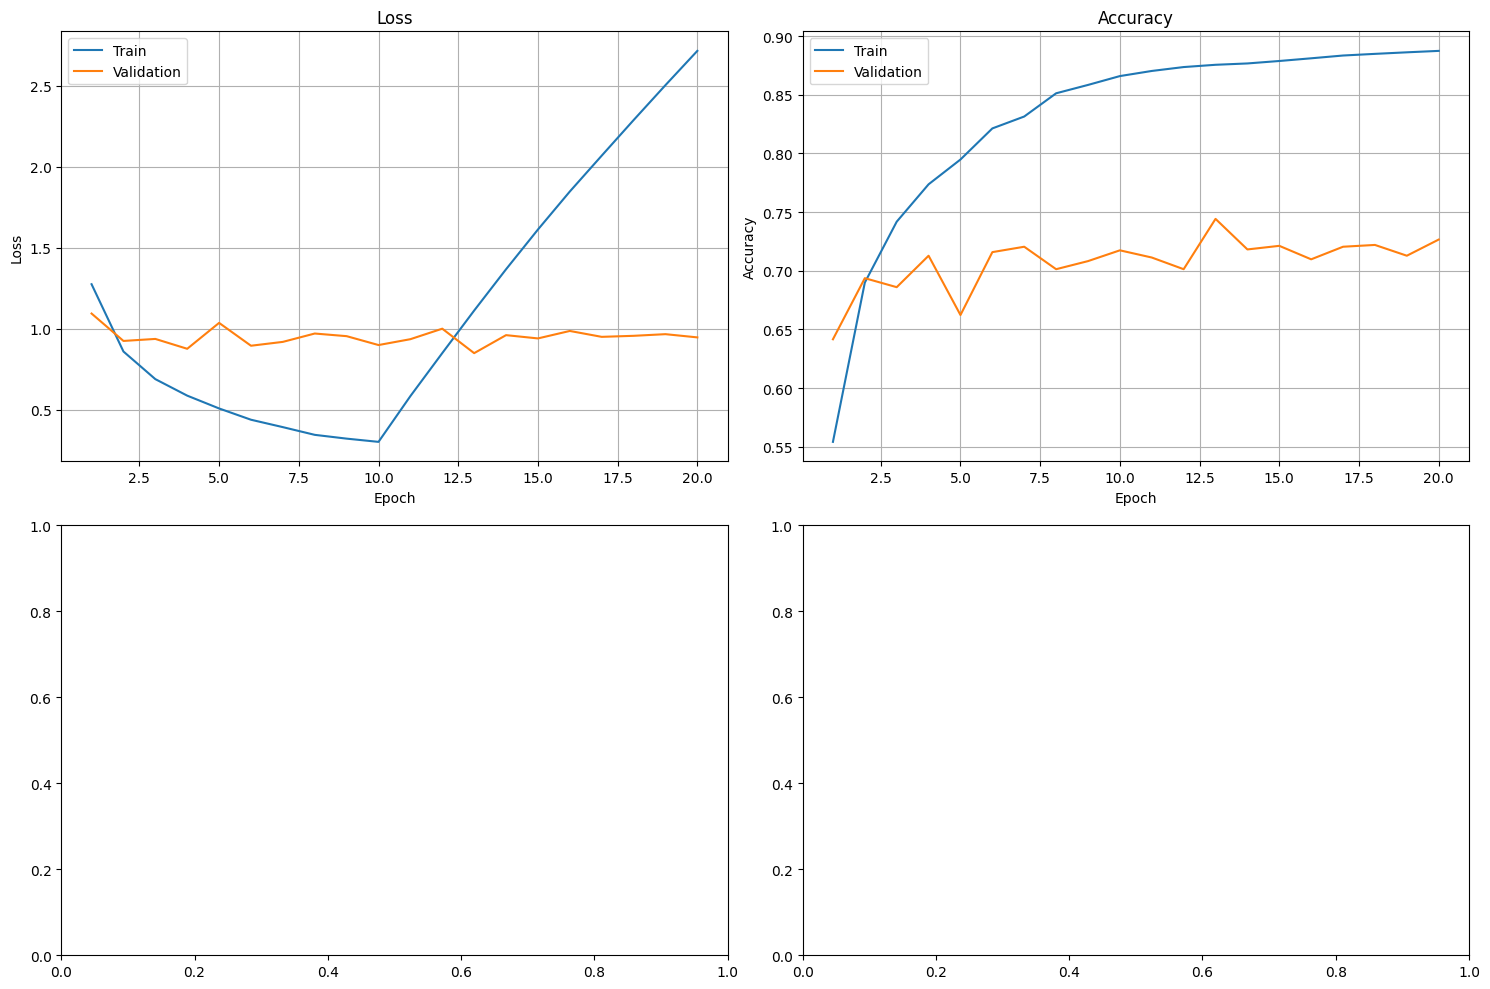

In [58]:

fig, axs = plt.subplots(2, 2, figsize=(15, 10))

epochs = range(1, len(history["train_loss"]) + 1)

# ============================
# Loss
# ============================
axs[0, 0].plot(epochs, history["train_loss"], label="Train")
axs[0, 0].plot(epochs, history["val_loss"], label="Validation")
axs[0, 0].set_title("Loss")
axs[0, 0].set_xlabel("Epoch")
axs[0, 0].set_ylabel("Loss")
axs[0, 0].grid(True)
axs[0, 0].legend()

# ============================
# Accuracy
# ============================
axs[0, 1].plot(epochs, history["train_acc"], label="Train")
axs[0, 1].plot(epochs, history["val_acc"], label="Validation")
axs[0, 1].set_title("Accuracy")
axs[0, 1].set_xlabel("Epoch")
axs[0, 1].set_ylabel("Accuracy")
axs[0, 1].grid(True)
axs[0, 1].legend()

# ============================
# Precision / Recall / F1
# ============================
'''axs[1, 0].plot(epochs, history["val_precision"], label="Precision")
axs[1, 0].plot(epochs, history["val_recall"], label="Recall")
axs[1, 0].plot(epochs, history["val_f1"], label="F1-score")
axs[1, 0].set_title("Validation Metrics")
axs[1, 0].set_xlabel("Epoch")
axs[1, 0].set_ylabel("Score")
axs[1, 0].grid(True)
axs[1, 0].legend()

# ============================
# Learning Rate
# ============================
axs[1, 1].plot(epochs, history["learning_rate"])
axs[1, 1].set_title("Learning Rate")
axs[1, 1].set_xlabel("Epoch")
axs[1, 1].set_ylabel("LR")
axs[1, 1].grid(True)'''

plt.tight_layout()
plt.show()

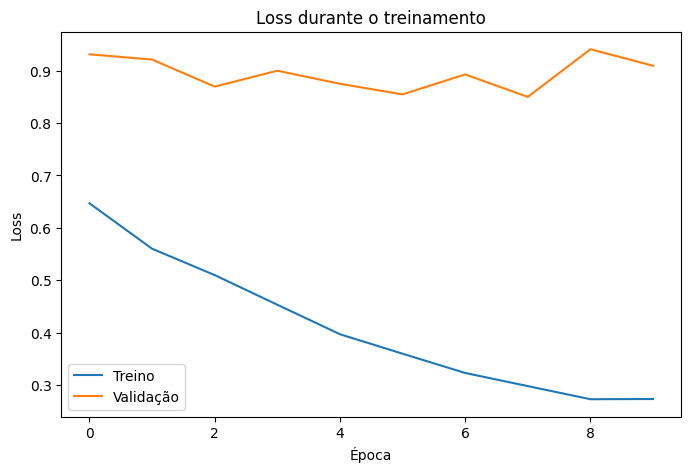

0.509090909090909


In [46]:
model.eval()

correct = 0

total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        labels = labels.to(device)

plt.figure(figsize=(8,5))

plt.plot(history["train_loss"], label="Treino")
plt.plot(history["val_loss"], label="Validação")

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Loss durante o treinamento")
plt.legend()

plt.show()

outputs = model(images)

pred = outputs.logits.argmax(1)

correct += (pred == labels).sum().item()

total += labels.size(0)

print(correct / total)

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import torch

=== Relatório de Classificação por Classe ===
              precision    recall  f1-score   support

       akiec       0.39      0.36      0.37        53
         bcc       0.38      0.91      0.54        81
         bkl       0.50      0.47      0.48       135
          df       0.50      0.31      0.38        13
         mel       0.47      0.48      0.48       129
          nv       0.92      0.82      0.87       880
        vasc       0.53      0.53      0.53        15

    accuracy                           0.73      1306
   macro avg       0.53      0.55      0.52      1306
weighted avg       0.77      0.73      0.74      1306



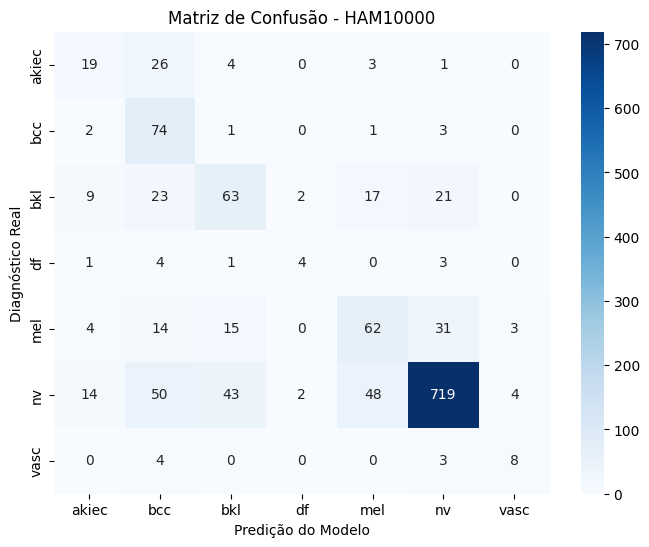

In [59]:
all_preds = []
all_labels = []

# 2. Loop para coletar as previsões do seu DataLoader de validação/teste
# (Substitua 'val_dataloader' pelo nome da sua variável de validação)
with torch.no_grad():
    for batch in val_loader:
        # Usando o formato de lista (Cenário A do passo anterior)
        inputs = batch[0].to(device)
        labels = batch[1].to(device)
        
        # Roda o modelo e extrai o tensor de logits
        outputs = model(inputs)
        logits = outputs.logits 
        
        # Pega a classe com maior probabilidade
        preds = torch.argmax(logits, dim=1)
        
        # Armazena os resultados
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 3. Mapeamento das 7 classes do HAM10000 (mantenha a ordem exata do seu encoder)
target_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

# --- RELATÓRIO POR CLASSE ---
print("=== Relatório de Classificação por Classe ===")
print(classification_report(all_labels, all_preds, target_names=target_names))

# --- MATRIZ DE CONFUSÃO VISUAL ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.ylabel('Diagnóstico Real')
plt.xlabel('Predição do Modelo')
plt.title('Matriz de Confusão - HAM10000')
plt.show()

=== Relatório de Classificação por Classe ===
              precision    recall  f1-score   support

       akiec       0.36      0.38      0.37        48
         bcc       0.28      0.86      0.43        66
         bkl       0.56      0.52      0.54       172
          df       0.55      0.60      0.57        10
         mel       0.56      0.56      0.56       186
          nv       0.94      0.82      0.87      1016
        vasc       0.61      0.66      0.63        29

    accuracy                           0.74      1527
   macro avg       0.55      0.63      0.57      1527
weighted avg       0.79      0.74      0.75      1527



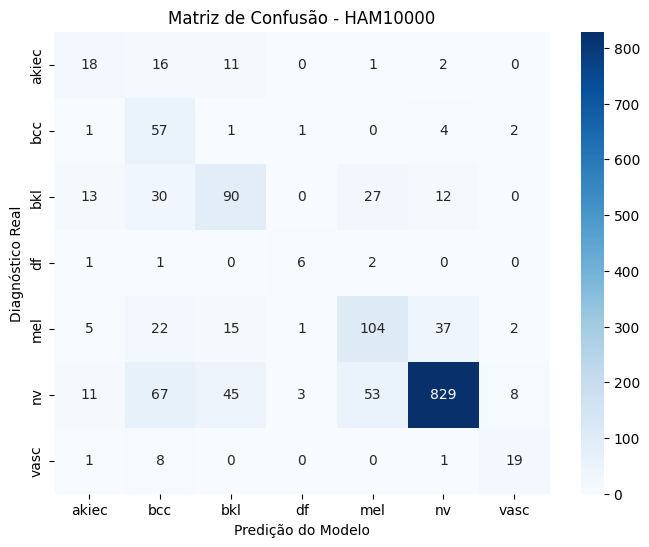

In [60]:
all_preds = []
all_labels = []

# 2. Loop para coletar as previsões do seu DataLoader de validação/teste
# (Substitua 'val_dataloader' pelo nome da sua variável de validação)
with torch.no_grad():
    for batch in test_loader:
        # Usando o formato de lista (Cenário A do passo anterior)
        inputs = batch[0].to(device)
        labels = batch[1].to(device)
        
        # Roda o modelo e extrai o tensor de logits
        outputs = model(inputs)
        logits = outputs.logits 
        
        # Pega a classe com maior probabilidade
        preds = torch.argmax(logits, dim=1)
        
        # Armazena os resultados
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 3. Mapeamento das 7 classes do HAM10000 (mantenha a ordem exata do seu encoder)
target_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

# --- RELATÓRIO POR CLASSE ---
print("=== Relatório de Classificação por Classe ===")
print(classification_report(all_labels, all_preds, target_names=target_names))

# --- MATRIZ DE CONFUSÃO VISUAL ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.ylabel('Diagnóstico Real')
plt.xlabel('Predição do Modelo')
plt.title('Matriz de Confusão - HAM10000')
plt.show()

In [52]:
torch.save(
        model.state_dict(),
        "best_vit_ham10000.pth")

In [50]:
!ls

best_vit_ham10000.pth
